In [2]:
import xarray as xr 
from anemoi.datasets import open_dataset
import numpy as np
import yaml
import os 
import cfgrib
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pathlib
import csv
import matplotlib.patches as mpatches

## Lower resolution on CERRA

In [3]:
cerra_outer=xr.open_dataset("cerra_outer.zarr")
def outline_lonlat(ds):
    lat = ds["latitude"].values
    lon = ds["longitude"].values

    edge_lon = np.concatenate([
        lon[0, :],
        lon[:, -1],
        lon[-1, ::-1],
        lon[::-1, 0],
    ])
    edge_lat = np.concatenate([
        lat[0, :],
        lat[:, -1],
        lat[-1, ::-1],
        lat[::-1, 0],
    ])
    return edge_lon, edge_lat


In [4]:
ds = xr.open_dataset("cerra_outer.zarr", engine="zarr")

lon_min, lon_max = -3.5, 3.0
lat_min, lat_max = 50.5, 55.0

lon2d = ds["longitude"].values
lat2d = ds["latitude"].values

mask = (
    (lon2d >= lon_min) & (lon2d <= lon_max) &
    (lat2d >= lat_min) & (lat2d <= lat_max)
)


yy, xx = np.where(mask)
y0, y1 = int(yy.min()), int(yy.max())
x0, x1 = int(xx.min()), int(xx.max())

# Inner high-res dataset (still CERRA grid, just smaller)
cerra_HR = ds.isel(y=slice(y0, y1+1), x=slice(x0, x1+1))


In [ ]:
factor = 5  # ~27 km

# coarsen all variables that live on (y,x)
vars_xy = [v for v in ds.data_vars if {'y','x'}.issubset(ds[v].dims)]
ds_xy = ds[vars_xy].coarsen(y=factor, x=factor, boundary="trim").mean()

# coarsen coords too
lat_c = ds["latitude"].coarsen(y=factor, x=factor, boundary="trim").mean()
lon_c = ds["longitude"].coarsen(y=factor, x=factor, boundary="trim").mean()

cerra_LR = ds_xy.assign_coords(latitude=lat_c, longitude=lon_c)
#cerra_outer_coarse.to_zarr("cerra_outer_coarse.zarr", mode="w"

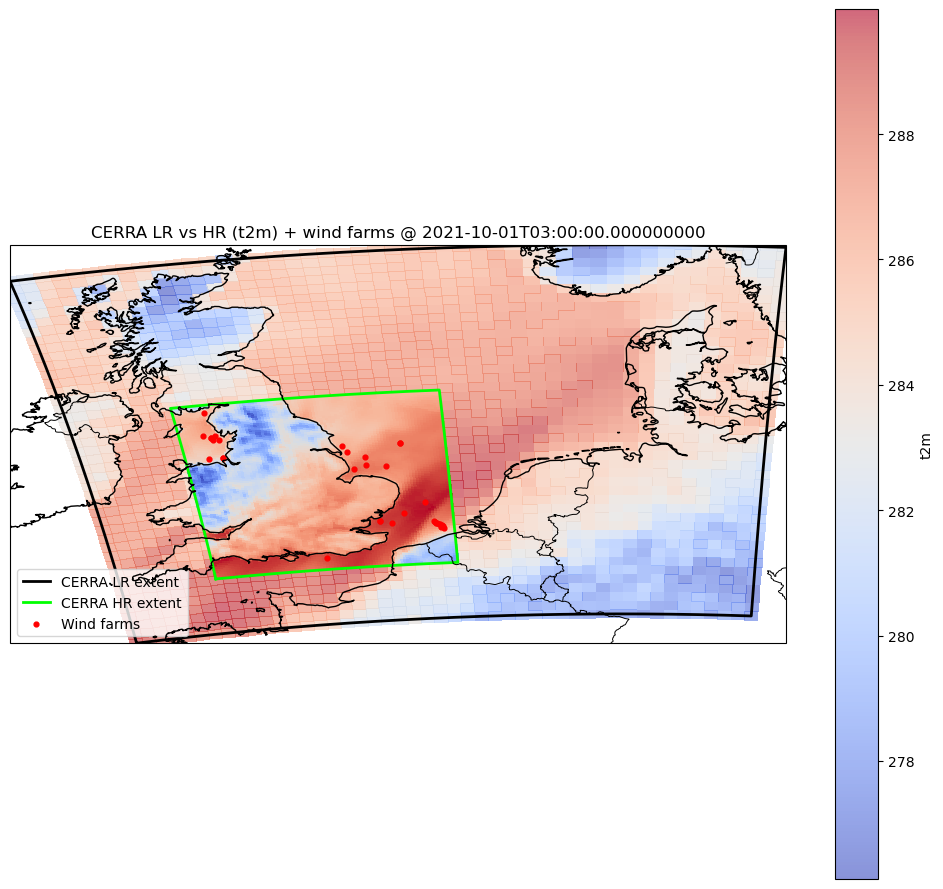

In [ ]:

meta_path = Path("/mnt/weatherloss/WindPower/data/NorthSea/Power/windfarm_metadata.csv")
farms = []
with meta_path.open("r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        farms.append((float(row["lat"]), float(row["lon"])))
farm_lats, farm_lons = zip(*farms)
farm_lons = np.array(farm_lons)

varname = "t2m"  # change if needed
da_lr = cerra_LR[varname]
da_hr = cerra_HR[varname]

if "time" in da_lr.dims:
    t_idx = np.random.randint(da_lr.sizes["time"])
    da_lr = da_lr.isel(time=t_idx)
    da_hr = da_hr.isel(time=t_idx)
    timestamp = str(cerra_LR["time"].isel(time=t_idx).values)

lon_lr = cerra_LR["longitude"].values
if np.nanmax(lon_lr) > 180:
    farm_lons_plot = np.where(farm_lons < 0, farm_lons + 360, farm_lons)
else:
    farm_lons_plot = farm_lons

# ---- plot ----
fig = plt.figure(figsize=(10, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

# extent to LR domain
lat_lr = cerra_LR["latitude"].values
ax.set_extent(
    [np.nanmin(lon_lr), np.nanmax(lon_lr), np.nanmin(lat_lr), np.nanmax(lat_lr)],
    crs=ccrs.PlateCarree(),
)

# LR background
da_lr.plot(
    ax=ax, x="longitude", y="latitude",
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    alpha=0.6,
    zorder=1,
    add_colorbar=True,
)

# HR overlay
da_hr.plot(
    ax=ax, x="longitude", y="latitude",
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    zorder=3,
    add_colorbar=False,
)

# outlines
lr_lon, lr_lat = outline_lonlat(cerra_LR)
hr_lon, hr_lat = outline_lonlat(cerra_HR)

ax.plot(lr_lon, lr_lat, color="black", linewidth=2,
        transform=ccrs.PlateCarree(), label="CERRA LR extent", zorder=4)
ax.plot(hr_lon, hr_lat, color="lime", linewidth=2,
        transform=ccrs.PlateCarree(), label="CERRA HR extent", zorder=5)

# wind farms
ax.scatter(
    farm_lons_plot, farm_lats,
    color="red", s=12,
    transform=ccrs.PlateCarree(),
    zorder=6,
    label="Wind farms"
)

# map features
ax.coastlines(zorder=7)
ax.add_feature(cfeature.BORDERS, linewidth=0.7, zorder=7)

ax.legend(loc="lower left")
ax.set_title(f"CERRA LR vs HR ({varname}) + wind farms @ {timestamp}")

plt.tight_layout()
plt.show()
